# Machine learning

This notebook corresponds to the second part of the project, and contains results for the train/test split by date.

The following regression methods are used:
- Linear regression
- Random forest regression
- Ridge regression
- Gradient boosting regression

Each method in turn is fit on the train and test data, and the predictions on the test data are plotted alongside the predictions from the chemical box model (minimal input) and ATom measurements.

Random forest regression and gradient boosting regression also have an additional attribute called feature importance and the plots for this are shown too.

---

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import pytz
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib as mpl

In [4]:
df = pd.read_csv("box_model_output.csv")
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['date'] = df['UTC_Start_dt']

In [5]:
scaler = StandardScaler()

df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
df_inputs_HO2 = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M', 'HO2_ATHOS']]

X = df_inputs
X_HO2 = df_inputs_HO2
y = df["[OH]_measured"]

X_train = df_inputs[df["date"] < "2016-08-22"]
X_train_normalised = scaler.fit_transform(X_train)

X_train_HO2 = df_inputs_HO2[df["date"] < "2016-08-22"]
X_train_normalised_HO2 = scaler.fit_transform(X_train_HO2)

y_train = df[["[OH]_measured"]][df["date"] < "2016-08-22"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-22")]
X_test_normalised = scaler.fit_transform(X_test)

X_test_HO2 = df_inputs_HO2[(df["date"] > "2016-08-22")]
X_test_normalised_HO2 = scaler.fit_transform(X_test_HO2)

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-22")]

In [6]:
# Creates a list of indexes for the date of 22/08/2016 for easier plotting later
indexes = df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")].count()

### Linear regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimise the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.

Model score on training data: 0.491
Model score on testing data: 0.342
===
WITH HO2 IN FEATURES
Model score on training data: 0.573
Model score on testing data: 0.492


Text(0.5, 1.0, '23/08/2016')

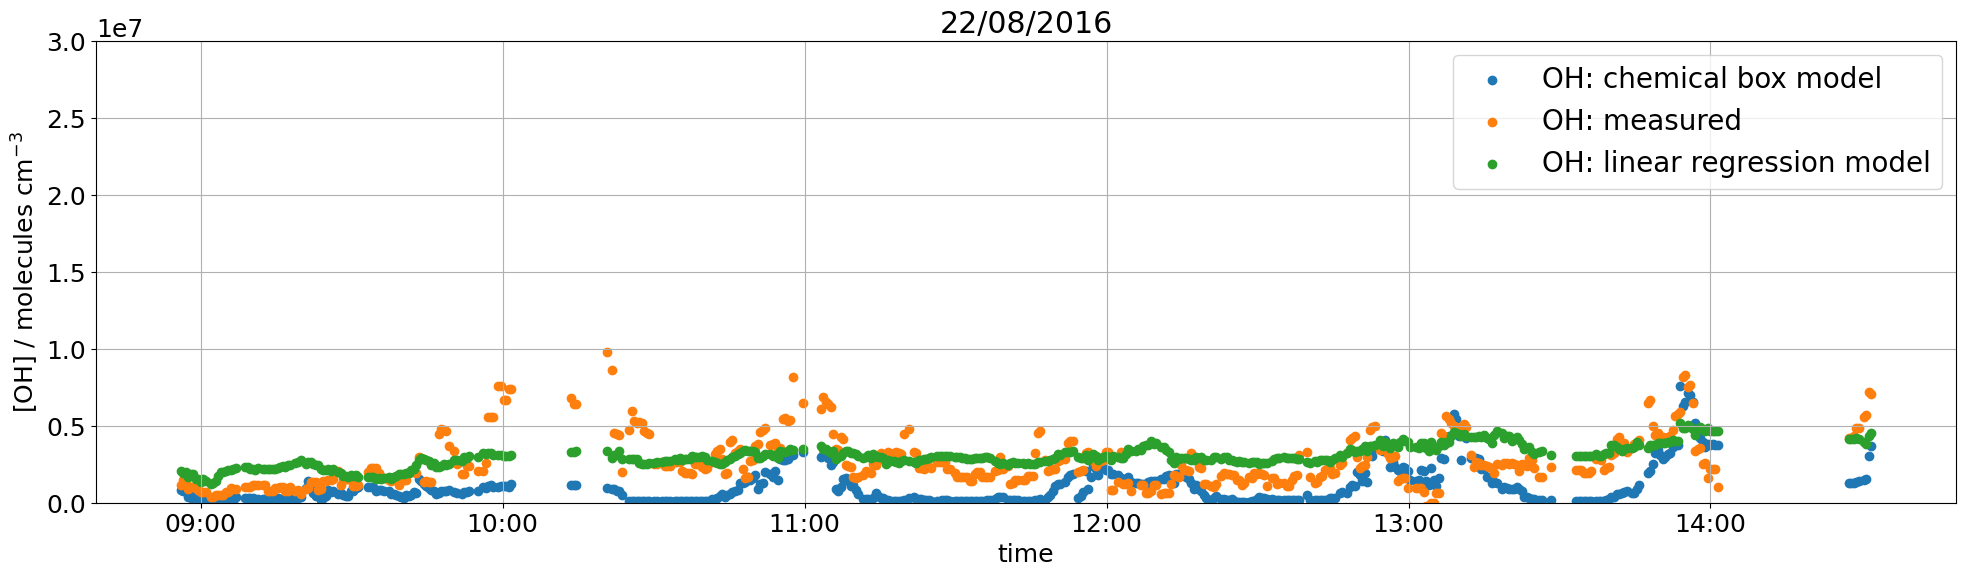

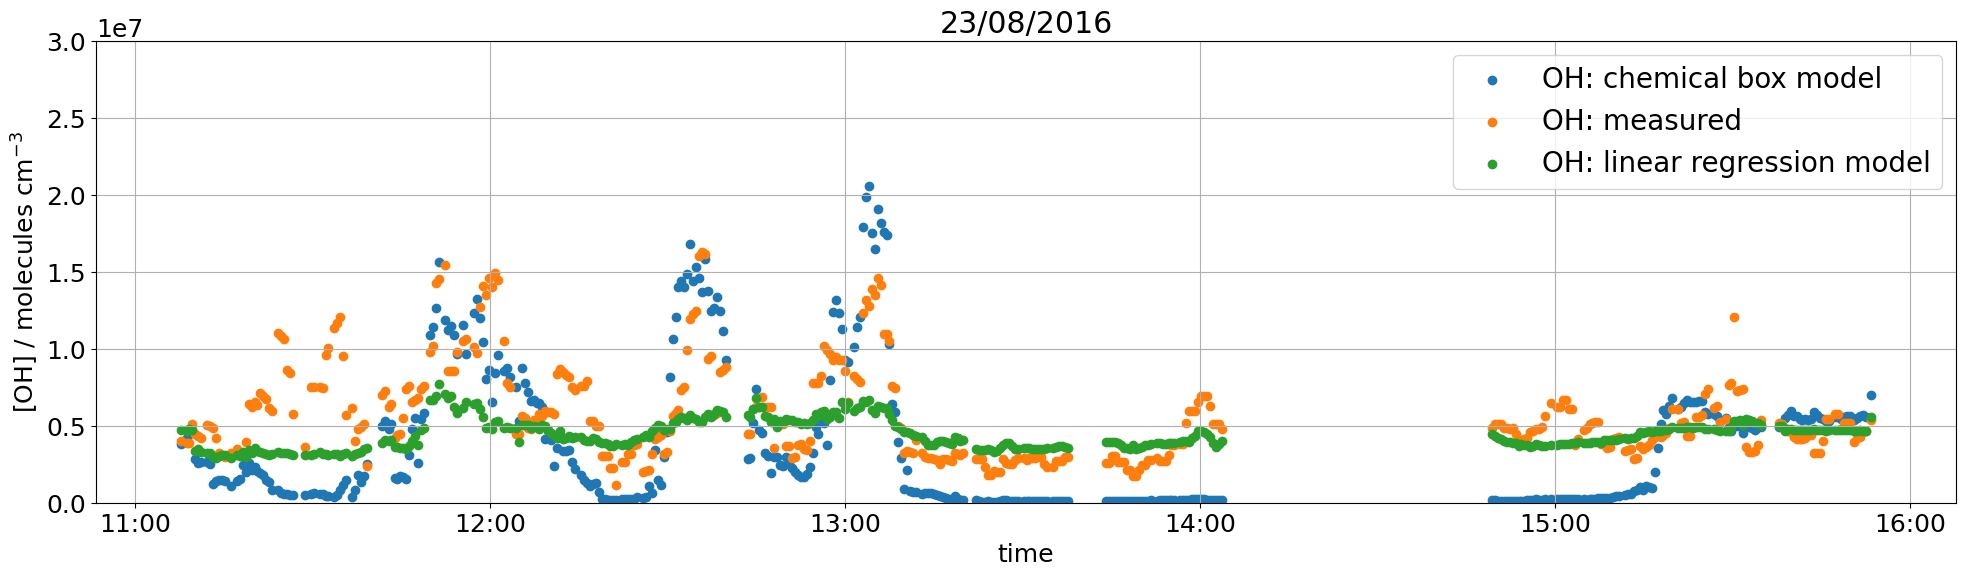

In [8]:
reg = LinearRegression().fit(X_train, y_train)
pred_reg = reg.predict(X_test)

reg_HO2 = LinearRegression().fit(X_train_HO2, y_train)
pred_reg_HO2 = reg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {round(reg.score(X_train, y_train), 3)}")
print(f"Model score on testing data: {round(reg.score(X_test, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(reg_HO2.score(X_train_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(reg_HO2.score(X_test_HO2, y_test), 3)}")

mpl.rcParams["font.size"] = 18

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_reg[0:indexes], label="OH: linear regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_reg[indexes:], label="OH: linear regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


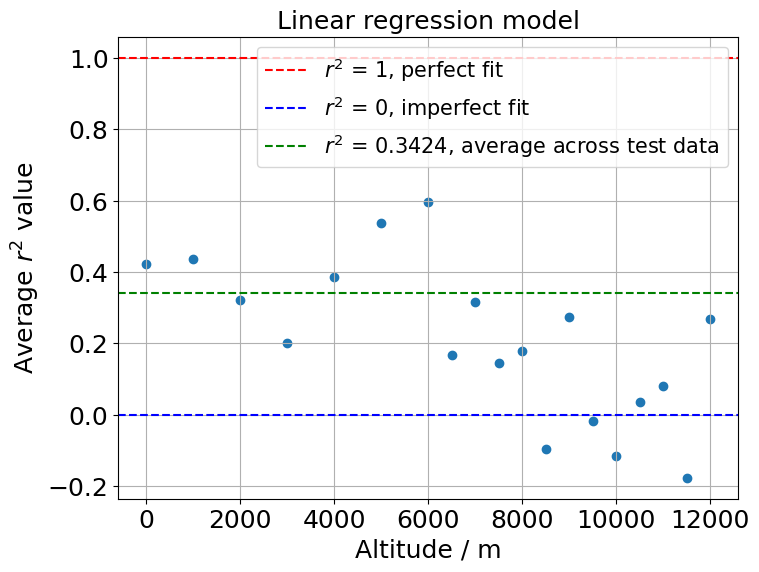

In [9]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(reg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))


fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (reg.score(X_test, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(reg.score(X_test, y_test), 4)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Linear regression model")
plt.legend(prop={'size':15})

plt.grid()

In [10]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_reg)):.2e}")
print(f"RMSE with HO2: {np.sqrt(mean_squared_error(y_test, pred_reg_HO2)):.2e}")

RMSE: 2.27e+06
RMSE with HO2: 1.99e+06


### Ridge regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

Ridge regression is an example of a regularisation procedure, which is an extension of the linear model.

This model solves a regression model where the loss function is the linear least squares function and regularization is given by the l2-norm

Used when there is collinearity in input values and ordinary least squares would overfit training data.

Model score on training data: 0.491
Model score on testing data:  0.214
===
WITH HO2 IN FEATURES
Model score on training data: 0.573
Model score on testing data: 0.313


Text(0.5, 1.0, '23/08/2016')

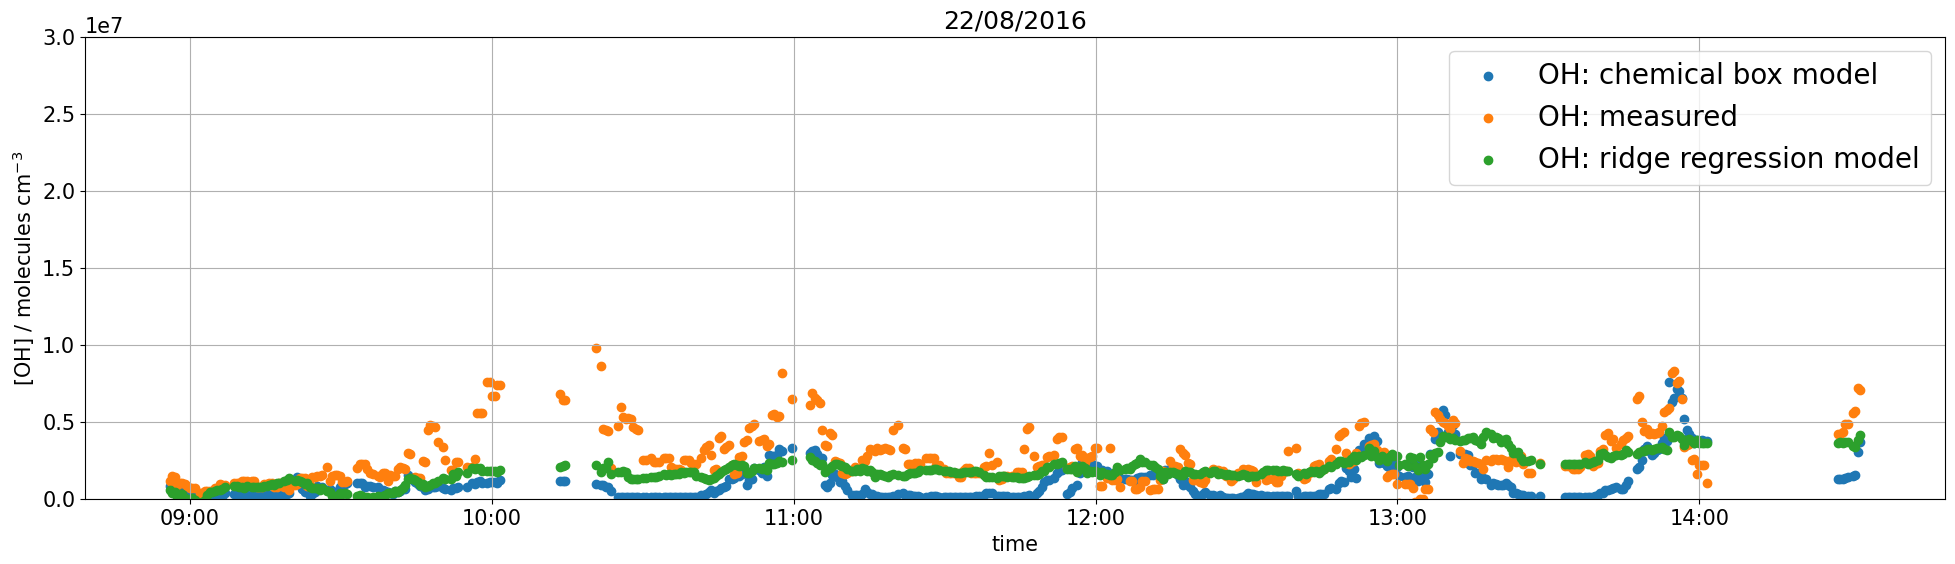

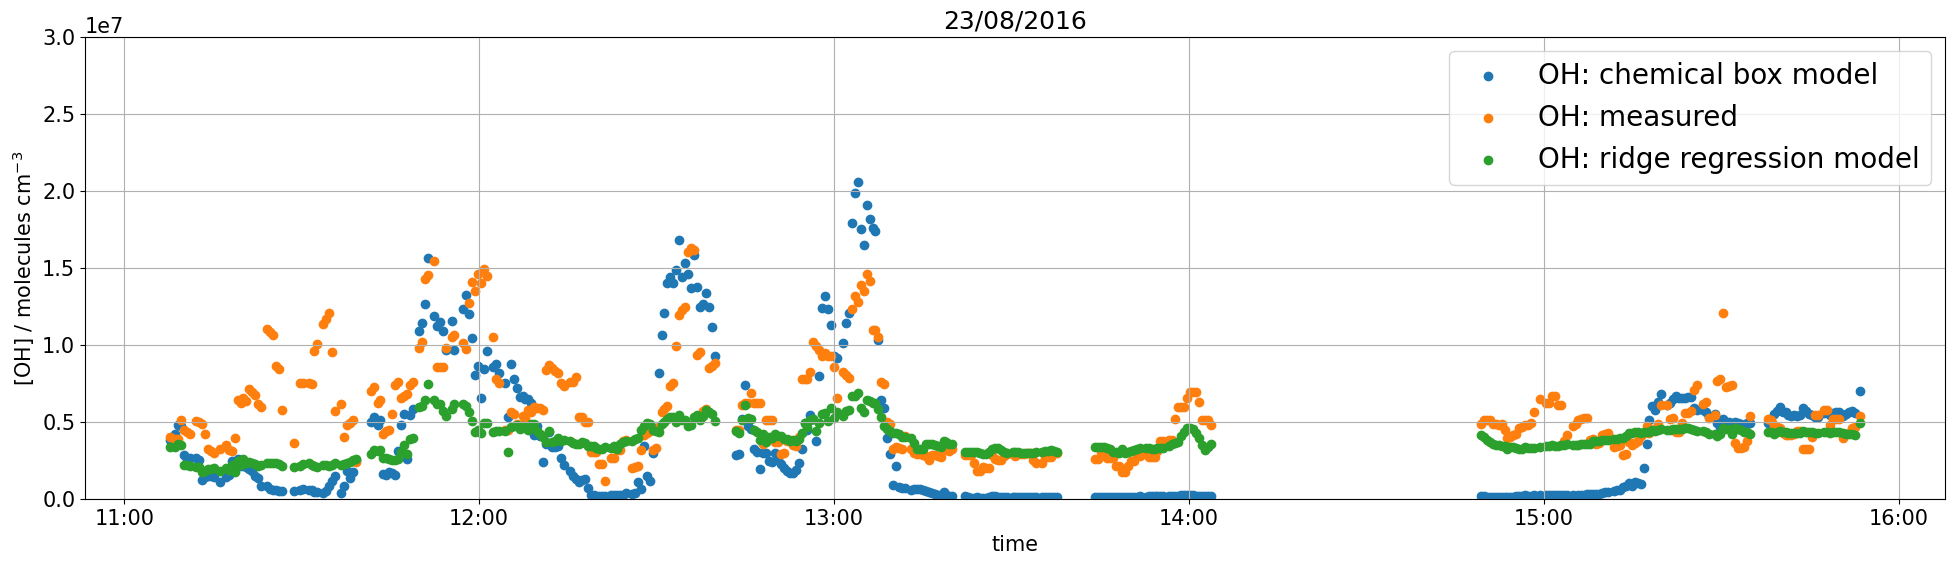

In [12]:
X_train_normalised = scaler.fit_transform(X_train)
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-22")]
X_test_normalised = scaler.fit_transform(X_test)

ridgereg = Ridge()
ridgereg.fit(X_train_normalised, y_train)

pred_ridgereg = ridgereg.predict(X_test_normalised)

ridgereg_HO2 = Ridge()
ridgereg_HO2.fit(X_train_normalised_HO2, y_train)

pred_ridgereg_HO2 = ridgereg_HO2.predict(X_test_normalised_HO2)

print(f"Model score on training data: {round(ridgereg.score(X_train_normalised, y_train), 3)}")
print(f"Model score on testing data:  {round(ridgereg.score(X_test_normalised, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(ridgereg_HO2.score(X_train_normalised_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(ridgereg_HO2.score(X_test_normalised_HO2, y_test), 3)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_ridgereg[0:indexes], label="OH: ridge regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label = "OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label = "OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_ridgereg[indexes:], label = "OH: ridge regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


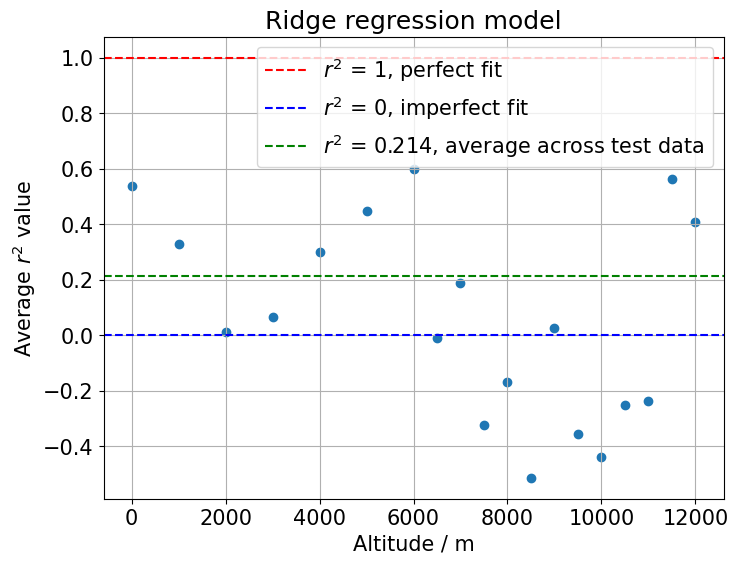

In [13]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(ridgereg.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (ridgereg.score(X_test_normalised, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(ridgereg.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Ridge regression model")
plt.legend(prop={'size':15})

plt.grid()

In [14]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_ridgereg)):.2e}")
print(f"RMSE with HO2: {np.sqrt(mean_squared_error(y_test, pred_ridgereg_HO2)):.2e}")

RMSE: 2.48e+06
RMSE with HO2: 2.32e+06


### Random forest regression
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

A random forest is a meta estimator that fits a number of decision tree regressors on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model score on training data: 0.964
Model score on testing data: 0.291
===
WITH HO2 IN FEATURES
Model score on training data: 0.969
Model score on testing data: 0.413


Text(0.5, 1.0, '23/08/2016')

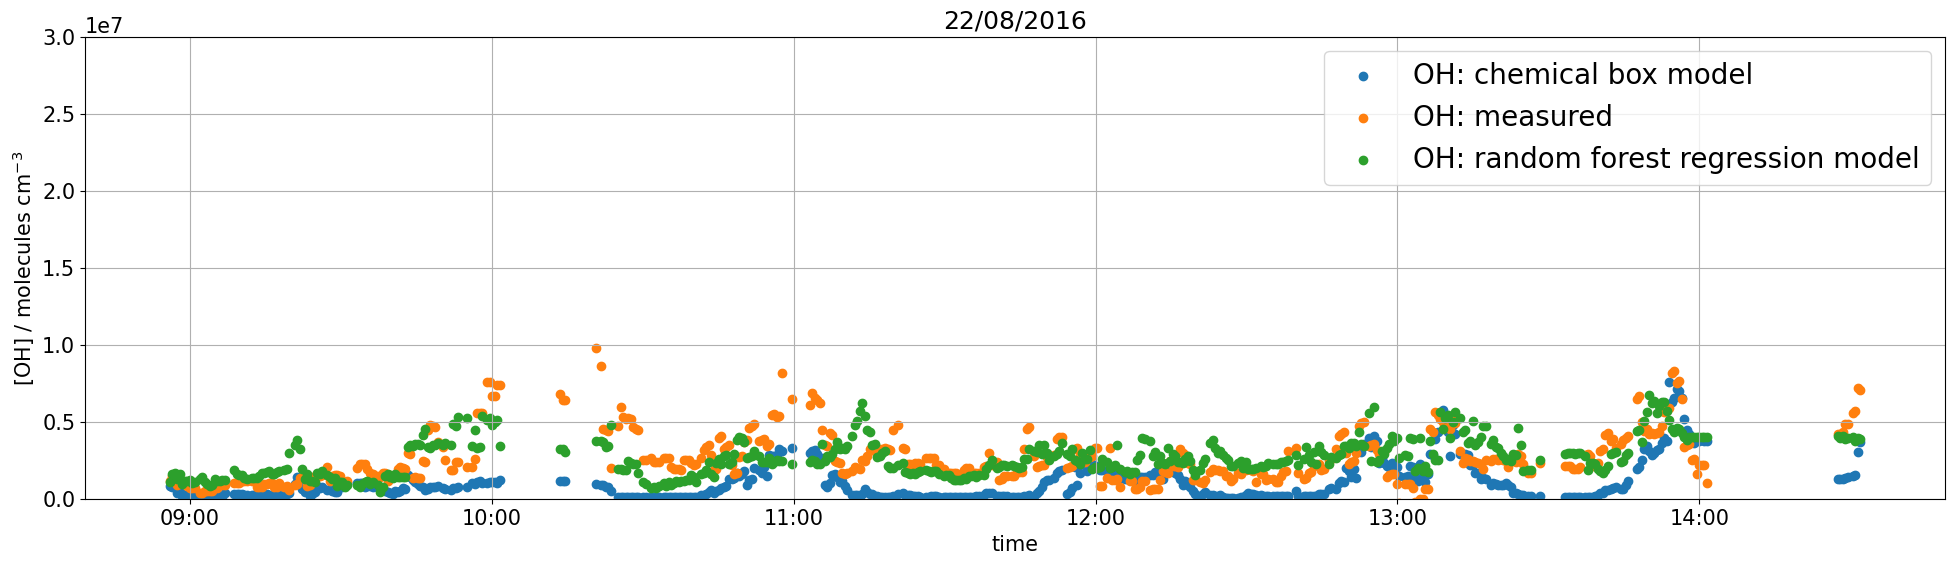

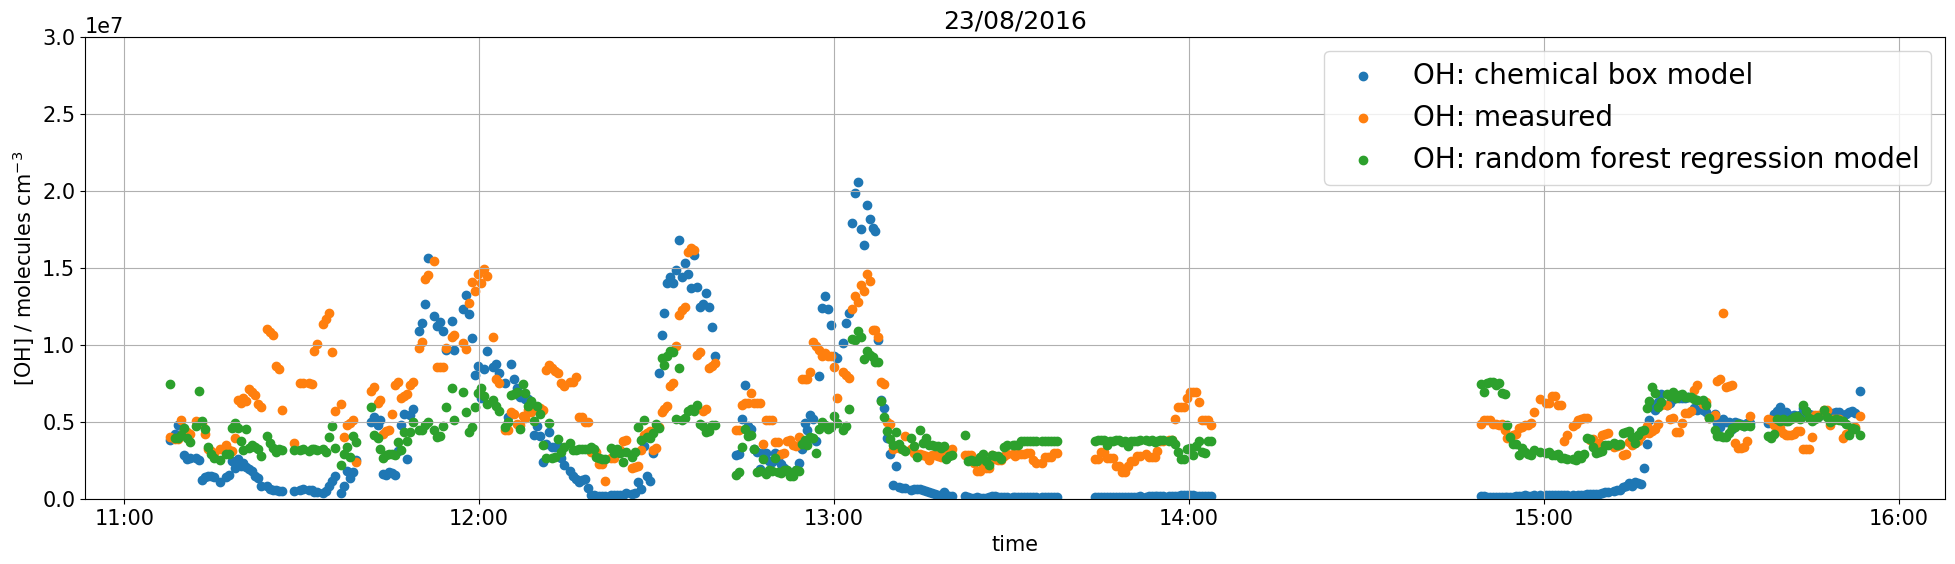

In [16]:
rfreg = RandomForestRegressor()
rfreg.fit(X_train, y_train)

pred_rfreg = rfreg.predict(X_test)

rfreg_HO2 = RandomForestRegressor()
rfreg_HO2.fit(X_train_HO2, y_train)

pred_rfreg_HO2 = rfreg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {round(rfreg.score(X_train, y_train), 3)}")
print(f"Model score on testing data: {round(rfreg.score(X_test, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(rfreg_HO2.score(X_train_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(rfreg_HO2.score(X_test_HO2, y_test), 3)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], pred_rfreg[0:indexes], label="OH: random forest regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], pred_rfreg[indexes:], label="OH: random forest regression model")
ax1.legend(prop={'size':20})


plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


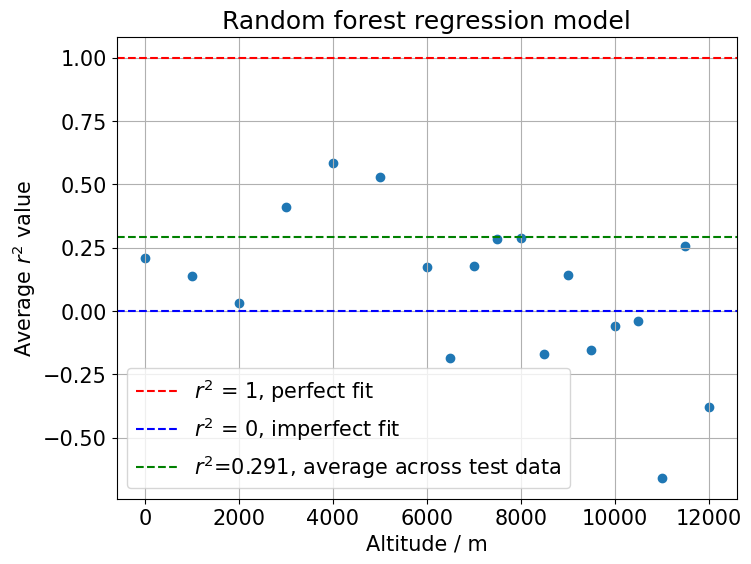

In [17]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(rfreg.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (rfreg.score(X_test, y_test)), color='g', linestyle='--', label=f'$r^2$={round(rfreg.score(X_test, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Random forest regression model")
plt.legend(prop={'size':15})

plt.grid()

In [18]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_rfreg)):.2e}")
print(f"RMSE with HO2: {np.sqrt(mean_squared_error(y_test, pred_rfreg_HO2)):.2e}")

RMSE: 2.35e+06
RMSE with HO2: 2.14e+06


### Feature importance with random forest

Text(0.5, 1.0, 'Random forest regression model')

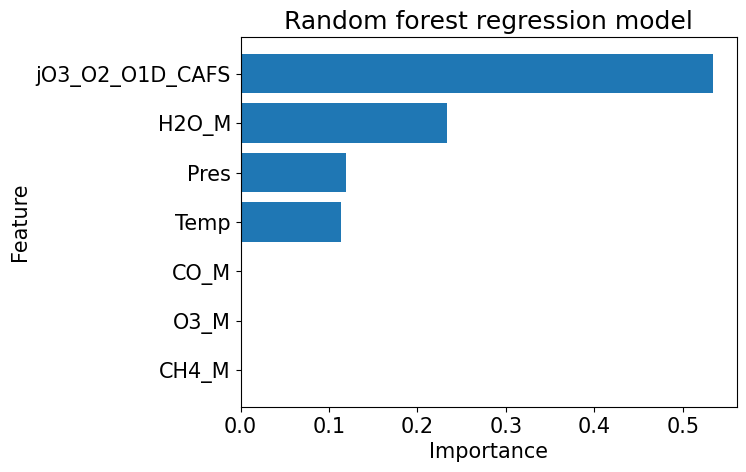

In [20]:
importances = rfreg.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random forest regression model")

Results are as expected - the production of OH depends strongly on the reaction between O(1D) and H2O and this process requires UV from sunlight.

### Gradient boosting
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

This algorithm builds an additive model in a forward stage-wise fashion. It produces a predictive model from an ensemble of weak predictive models

C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
C:\Users\Sophie\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Model score on training data: 0.824
Model score on testing data: 0.258
===
WITH HO2 IN FEATURES
Model score on training data: 0.834
Model score on testing data: 0.379


Text(0.5, 1.0, '23/08/2016')

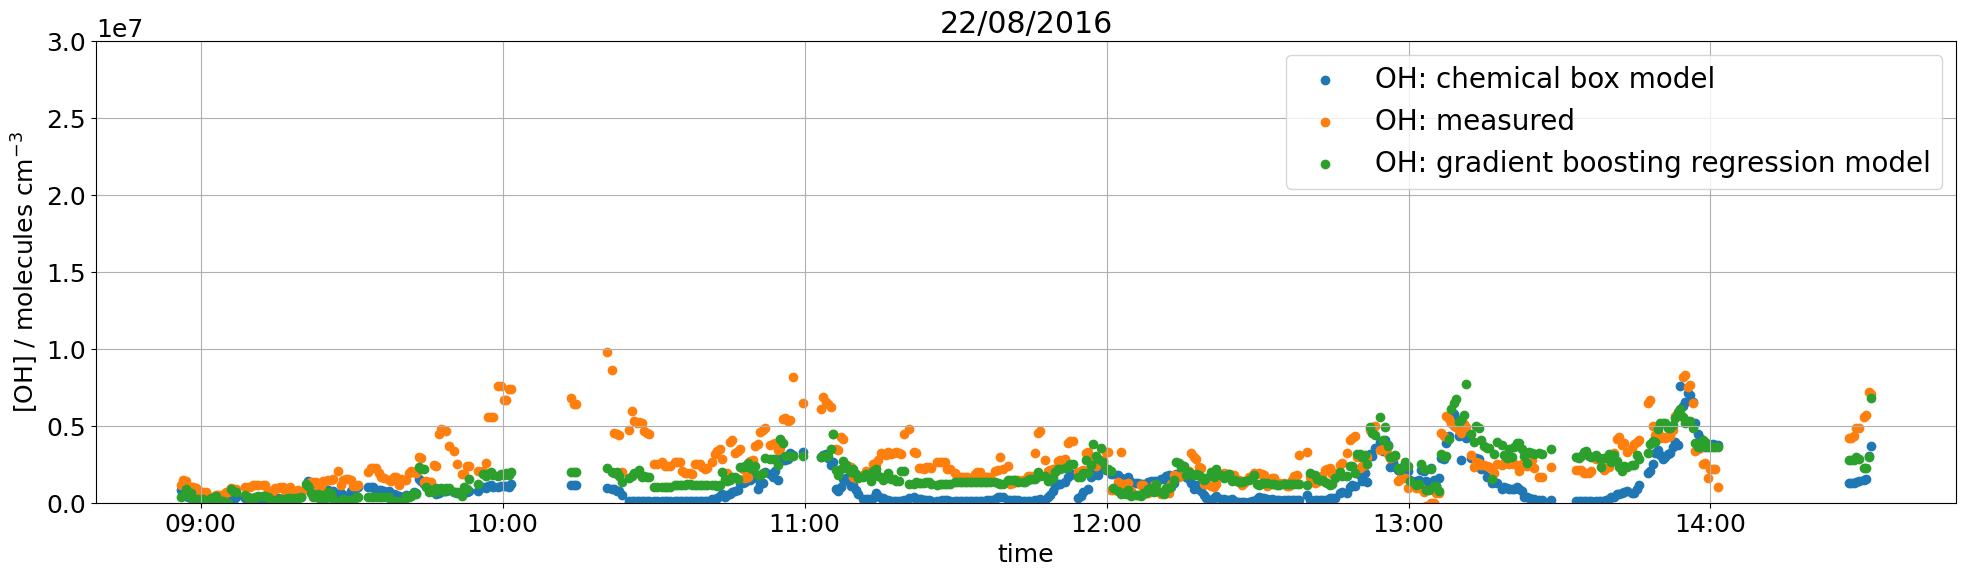

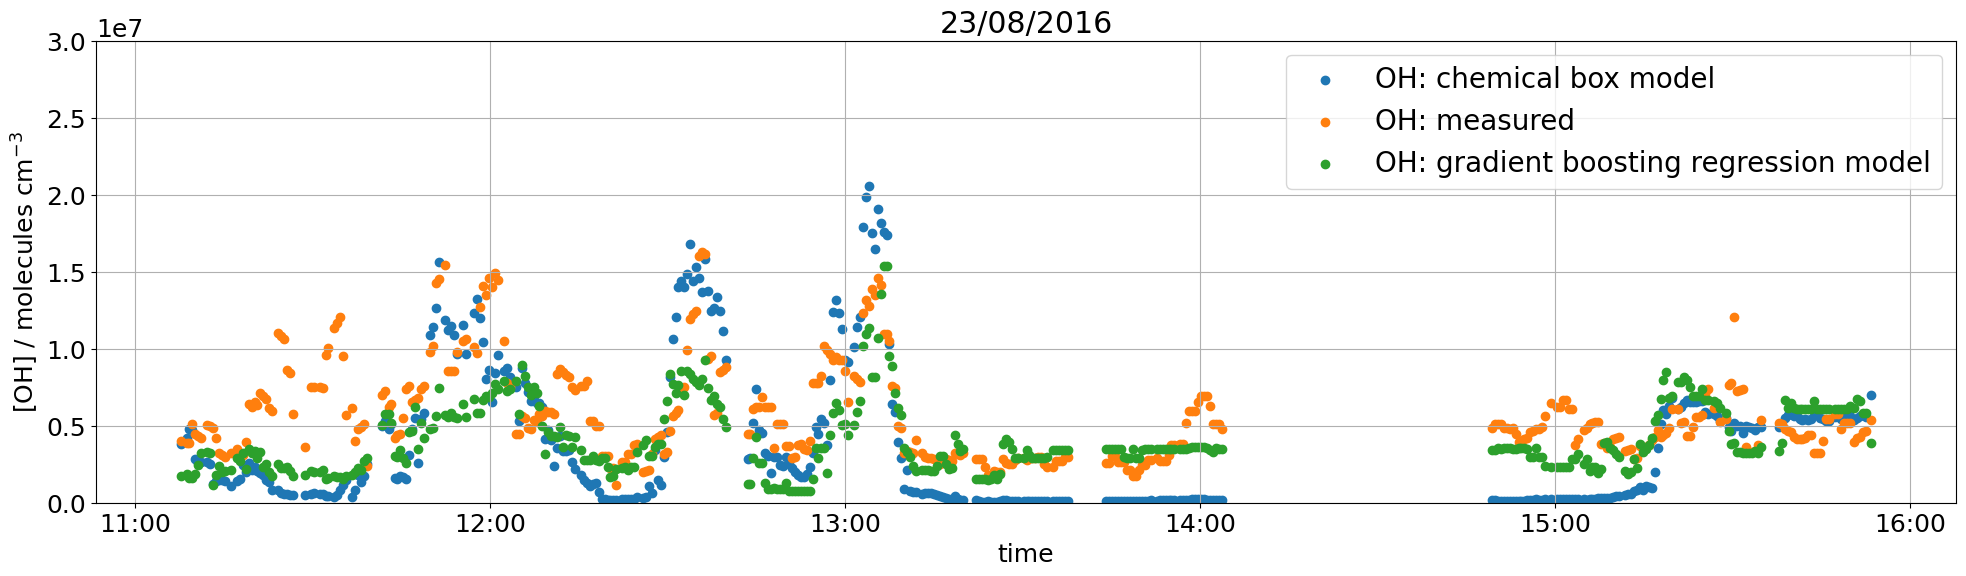

In [23]:
model = GradientBoostingRegressor()

model_HO2 = GradientBoostingRegressor()

model.fit(X_train_normalised, y_train)

model_HO2.fit(X_train_normalised_HO2, y_train)

y_pred = model.predict(X_test_normalised)

y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)

print(f"Model score on training data: {round(model.score(X_train_normalised, y_train), 3)}")
print(f"Model score on testing data: {round(model.score(X_test_normalised, y_test), 3)}")

print("===")
print("WITH HO2 IN FEATURES")

print(f"Model score on training data: {round(model_HO2.score(X_train_normalised_HO2, y_train), 3)}")
print(f"Model score on testing data: {round(model_HO2.score(X_test_normalised_HO2, y_test), 3)}")

mpl.rcParams["font.size"] = 18

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_test[0:indexes], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-22") & (df["date"] < "2016-08-23")], y_pred[0:indexes], label="OH: gradient boosting regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("22/08/2016")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('time')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=pytz.timezone("America/New_York")))
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], df["[OH]_calc"][(df["date"] > "2016-08-23")], label="OH: chemical box model")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_test[indexes:], label="OH: measured")
ax1.scatter(df["date"][(df["date"] > "2016-08-23")], y_pred[indexes:], label="OH: gradient boosting regression model")
ax1.legend(prop={'size':20})

plt.ylim(0, 3e7)
plt.grid()
plt.title("23/08/2016")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


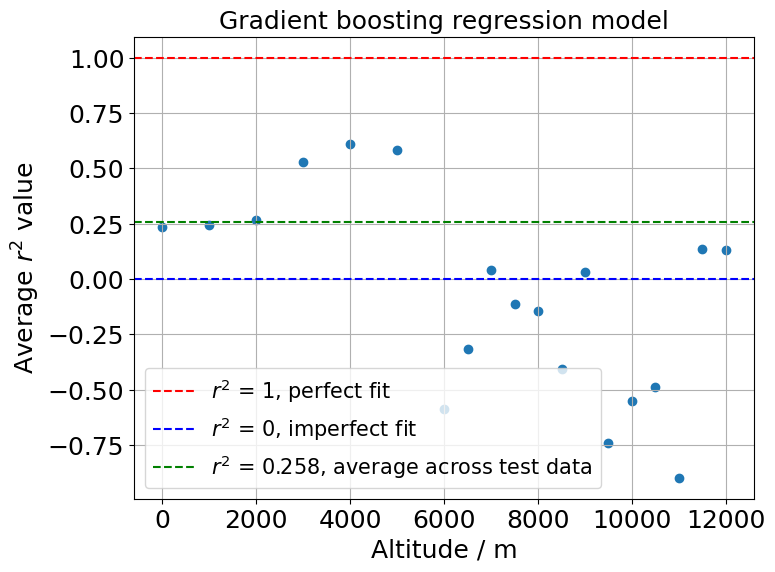

In [24]:
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    metrics_r2.append(model.score(X, y))

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (model.score(X_test_normalised, y_test)), color='g', linestyle='--', label=f'$r^2$ = {round(model.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("Gradient boosting regression model")
plt.legend(prop={'size':15})

plt.grid()

In [25]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2e}")
print(f"RMSE with HO2: {np.sqrt(mean_squared_error(y_test, y_pred_HO2)):.2e}")

RMSE: 2.41e+06
RMSE with HO2: 2.20e+06


Text(0.5, 1.0, 'Gradient boosting regression model')

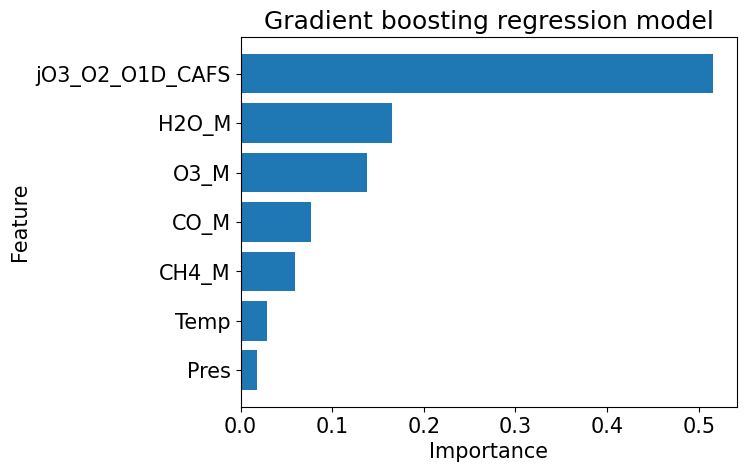

In [26]:
importances = model.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient boosting regression model")